In [105]:
# import required libraries
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [106]:
# Download latest version
path = kagglehub.dataset_download("rehanliaqat17/creidct-card")

In [107]:
file_name = "/creditcard.csv"
file_path = path + file_name

df = pd.read_csv(file_path)

In [108]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [113]:
# shape of the ataset
df.shape

# More info on data
df.info()

#statistical info on data
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [120]:
# Class distribution

class_counts = df["Class"].value_counts()
print(f"Class distribution: \n", class_counts)

fraud_percentage = class_counts[1]/len(df)*100.00
print(f"Fraud % in the dataset: {fraud_percentage: .4f} %")

Class distribution: 
 Class
0    284315
1       492
Name: count, dtype: int64
Fraud % in the dataset:  0.1727 %


Plotting class distribution


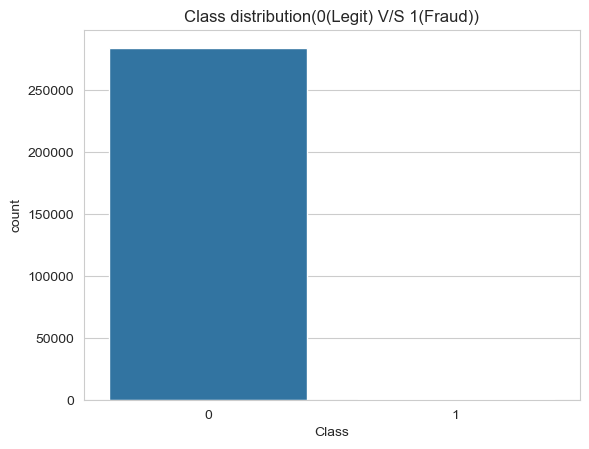

In [127]:
print("Plotting class distribution")

plt.figure()
sns.countplot(x="Class", data=df)
plt.title("Class distribution(0(Legit) V/S 1(Fraud))")
plt.show()

Plotting distribution of class based on the feature=Amount


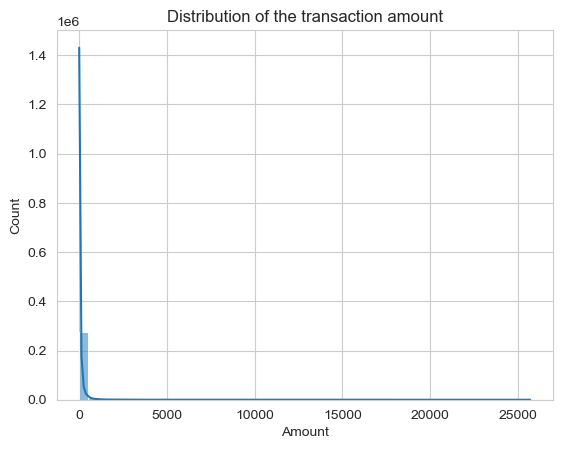

In [137]:
print("Plotting distribution of class based on the feature=Amount")

sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of the transaction amount")
plt.show()

Text(0.5, 1.0, 'Fraut V/S Legit Amount Comparision')

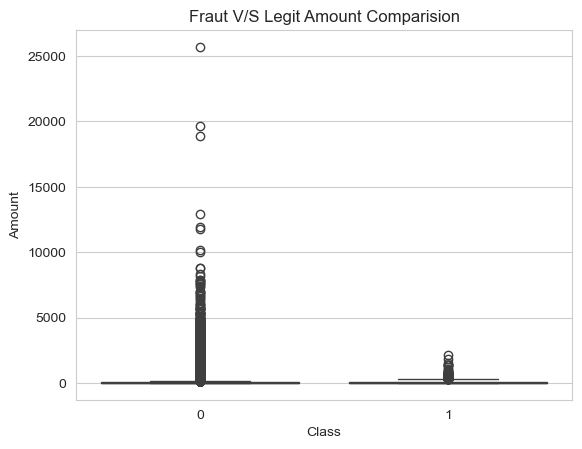

In [140]:
plt.figure()

sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Fraut V/S Legit Amount Comparision")

In [100]:
df[200:500]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
200,-1.571359,1.687508,0.734670,1.293350,-0.217532,-0.002677,0.147364,0.515362,-0.372442,0.078021,...,0.048549,0.377256,-0.030436,0.117608,-0.060520,-0.296550,-0.481570,-0.167897,10.00,0
201,0.709336,-0.011679,-0.530213,0.236331,1.611750,4.091915,-0.862138,1.083973,0.786796,0.112887,...,0.006775,0.090033,0.271773,0.986547,-0.809943,-0.529660,-0.065887,-0.125002,35.97,0
202,1.101762,-0.119018,1.139150,1.844961,-0.817909,0.247770,-0.684181,0.283096,0.286763,0.440946,...,0.120201,0.371305,-0.016047,0.113901,0.152014,1.126049,-0.038695,0.012339,22.37,0
203,1.207207,0.241318,0.258745,0.653335,-0.256426,-0.620309,-0.039653,-0.022139,0.145191,-0.305443,...,-0.267165,-0.780158,0.165657,0.012956,0.116176,0.126406,-0.012156,0.026239,4.57,0
204,-0.541889,0.907745,0.941842,0.993748,0.844724,0.360280,0.761737,-0.222477,0.179748,0.408008,...,-0.203112,-0.122944,-0.438462,-0.996350,0.093796,-0.216346,0.015375,-0.038491,23.57,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-1.209437,0.949446,-0.429811,-2.640094,2.601387,3.056966,0.473495,0.280729,0.853043,1.023893,...,-0.214920,-0.449815,-0.088677,1.030439,-0.048967,0.671979,-0.612153,-0.224000,0.68,0
496,-1.185698,-0.386510,1.623072,1.636406,1.102506,-0.683317,-0.303337,0.285653,-0.056085,-0.173921,...,0.068753,-0.006952,0.040889,0.040937,0.009224,-0.201042,0.106580,0.140465,9.99,0
497,1.020399,-0.639479,0.941568,0.121307,-0.996320,0.177803,-0.589656,0.153583,0.835979,-0.347747,...,-0.140624,-0.341663,-0.060548,0.116672,0.144624,0.932850,-0.049522,0.018131,97.47,0
498,1.256217,0.255028,0.277716,0.706677,-0.495831,-1.106735,-0.008493,-0.124504,0.243687,-0.241481,...,-0.303927,-0.943830,0.146551,0.307164,0.169070,0.099129,-0.032095,0.027743,1.29,0


Text(0.5, 1.0, 'Fraut V/S Legit log1p(Amount) Comparision')

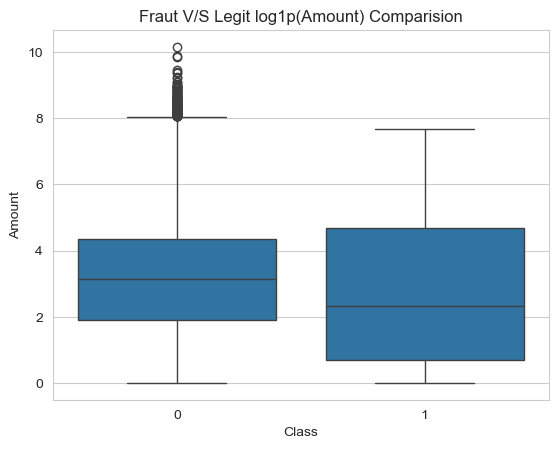

In [142]:
plt.figure()

sns.boxplot(x="Class", y=np.log1p(df["Amount"]), data=df)
plt.title("Fraut V/S Legit log1p(Amount) Comparision")

Checking correlation between the class and the other variables


Text(0.5, 1.0, 'Correlation heatmap')

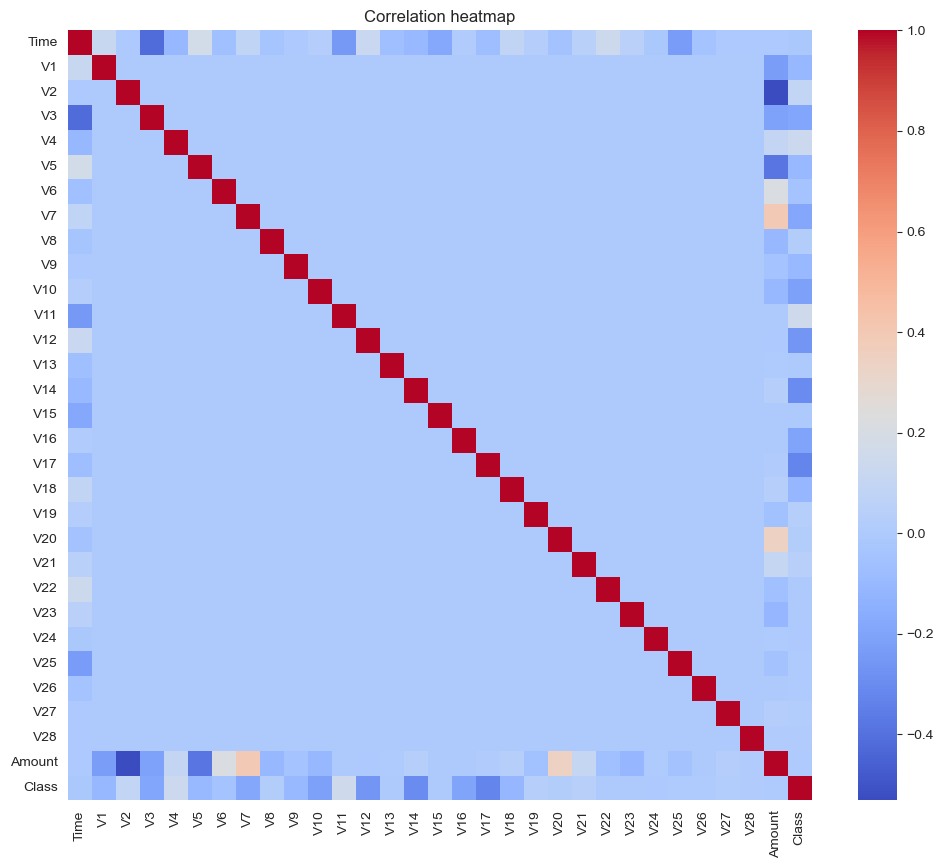

In [149]:
plt.figure(figsize=(12, 10))
print("Checking correlation between the class and the other variables")

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title("Correlation heatmap")
# print(correlation_matrix)

In [154]:
corr_with_target = correlation_matrix["Class"].sort_values(ascending=False)

print("Correlation with target \n")
print(corr_with_target)


Correlation with target 

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


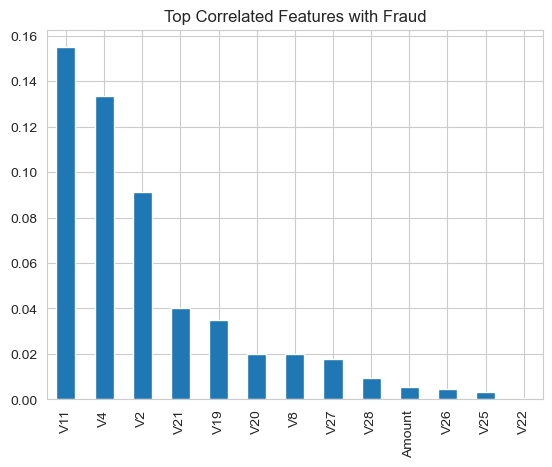

<Axes: >

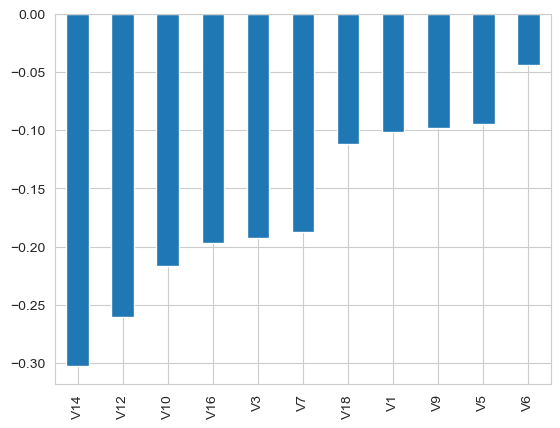

In [173]:
# Picking top correlations

top_positive_correlators = corr_with_target[1:14]
plt.figure()
top_positive_correlators.plot(kind='bar')
plt.title("Top Correlated Features with Fraud")
plt.show()

# top negative correlators
top_negative_correlators = correlation_matrix["Class"].sort_values(ascending=True)
top_negative_correlators = top_negative_correlators[1:12]
plt.figure()
top_negative_correlators.plot(kind='bar')